# 04 - Baseline: Logistic Regression outcome classifier

First real model. Uses the engineered features from `data/processed/{train,test}_features.csv` to predict `white_win`.

Steps:
1. Select feature columns, split into X/y
2. Standardize features (logistic regression is sensitive to feature scale — `material_diff` ranges roughly -40..40 while `mobility_diff` ranges roughly -80..90, so without scaling the optimizer weights them unevenly for reasons that have nothing to do with actual importance)
3. Fit `LogisticRegression` (sklearn's default is L2-regularized)
4. Evaluate: accuracy, precision, recall, F1, confusion matrix
5. Inspect learned coefficients against the correlations we already saw in the feature-engineering notebook

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

from src.features import extract_features

train_df = pd.read_csv('../data/processed/train_features.csv', low_memory=False)
test_df = pd.read_csv('../data/processed/test_features.csv', low_memory=False)

# derive feature column names from the extractor itself, so this list can't
# drift out of sync with src/features.py
feature_cols = list(extract_features(train_df['fen'].iloc[0]).keys())
print(f'{len(feature_cols)} features:', feature_cols)

24 features: ['white_pawns', 'white_knights', 'white_bishops', 'white_rooks', 'white_queens', 'black_pawns', 'black_knights', 'black_bishops', 'black_rooks', 'black_queens', 'material_diff', 'side_to_move_white', 'white_kingside_castle', 'white_queenside_castle', 'black_kingside_castle', 'black_queenside_castle', 'mobility_white', 'mobility_black', 'mobility_diff', 'white_center_control', 'black_center_control', 'center_control_diff', 'in_check', 'fullmove_number']


In [2]:
X_train, y_train = train_df[feature_cols], train_df['white_win']
X_test, y_test = test_df[feature_cols], test_df['white_win']

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((822936, 24),
 (208378, 24),
 np.float64(0.5189103405368096),
 np.float64(0.5140369904692434))

## Standardize features
Fit the scaler on train only, then apply it to test — the test set should never influence how features get scaled, same principle as not letting it influence training.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Fit logistic regression
`LogisticRegression()` with sklearn defaults uses L2 (ridge) regularization with strength `C=1.0` (smaller `C` = stronger regularization). We'll come back to tuning this later — for now, just get a working baseline.

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

## Evaluate
Accuracy alone can be misleading (recall the ~52/48 class balance, which is close to even here so it's less of a trap than the draw-inclusive case would've been, but still not the full picture) — precision, recall, and F1 tell you what kind of mistakes the model makes.

In [5]:
print(f'accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'precision: {precision_score(y_test, y_pred):.4f}')
print(f'recall:    {recall_score(y_test, y_pred):.4f}')
print(f'f1:        {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['black_win', 'white_win']))

accuracy:  0.6493
precision: 0.6376
recall:    0.7363
f1:        0.6834

              precision    recall  f1-score   support

   black_win       0.67      0.56      0.61    101264
   white_win       0.64      0.74      0.68    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



Text(0.5, 1.0, 'Confusion matrix - baseline logistic regression')

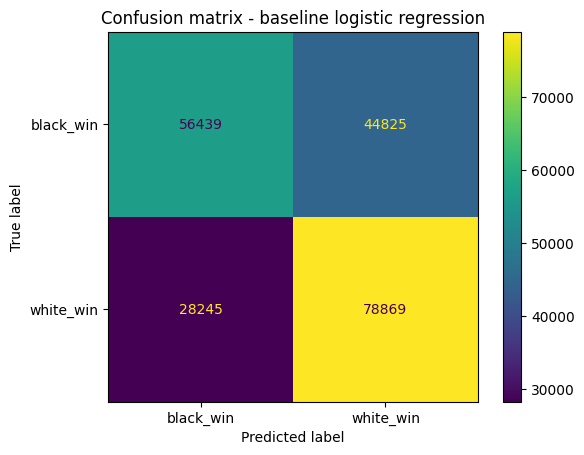

In [6]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=['black_win', 'white_win']
).plot()
plt.title('Confusion matrix - baseline logistic regression')

## Inspect learned coefficients
Since features were standardized, coefficient magnitude is directly comparable across features (that's one of the main reasons to standardize before logistic regression) — bigger |coefficient| means the model is leaning on that feature more. Check whether this matches the correlations we saw in `03_feature_engineering.ipynb`.

In [7]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0],
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,feature,coefficient
10,material_diff,0.790127
0,white_pawns,0.331702
5,black_pawns,-0.295464
7,black_bishops,-0.164430
2,white_bishops,0.151166
18,mobility_diff,0.116254
11,side_to_move_white,0.110204
1,white_knights,0.102482
13,white_queenside_castle,-0.092950
3,white_rooks,0.085160


## Experiment 1: drop redundant raw piece counts
Keep `material_diff` (already encodes the piece-value-weighted balance) and drop the 10 raw per-side piece-count columns that were sharing credit with it. A small helper makes each experiment below a clean, comparable run.

In [8]:
def run_experiment(name, feature_cols, model_kwargs=None, show_coefs=True):
    """Fit + evaluate a LogisticRegression variant, return a metrics dict for comparison."""
    model_kwargs = model_kwargs or {}

    scaler_fit = StandardScaler().fit(train_df[feature_cols])
    X_train_s = scaler_fit.transform(train_df[feature_cols])
    X_test_s = scaler_fit.transform(test_df[feature_cols])

    clf = LogisticRegression(max_iter=1000, **model_kwargs)
    clf.fit(X_train_s, y_train)
    preds = clf.predict(X_test_s)

    metrics = {
        'experiment': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'recall_black_win': recall_score(y_test, preds, pos_label=0),
    }

    print(name)
    print(classification_report(y_test, preds, target_names=['black_win', 'white_win']))

    if show_coefs:
        coefs = pd.DataFrame({'feature': feature_cols, 'coefficient': clf.coef_[0]})
        coefs = coefs.sort_values('coefficient', key=abs, ascending=False)
        print(coefs.to_string(index=False))

    return metrics, clf


results = []

In [9]:
results.append({
    'experiment': 'baseline (all 24 features)',
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'recall_black_win': recall_score(y_test, y_pred, pos_label=0),
})

reduced_feature_cols = [c for c in feature_cols if c not in [
    'white_pawns', 'white_knights', 'white_bishops', 'white_rooks', 'white_queens',
    'black_pawns', 'black_knights', 'black_bishops', 'black_rooks', 'black_queens',
]]
print(f'{len(reduced_feature_cols)} features (raw piece counts removed):', reduced_feature_cols)

metrics, _ = run_experiment('no raw piece counts', reduced_feature_cols)
results.append(metrics)

14 features (raw piece counts removed): ['material_diff', 'side_to_move_white', 'white_kingside_castle', 'white_queenside_castle', 'black_kingside_castle', 'black_queenside_castle', 'mobility_white', 'mobility_black', 'mobility_diff', 'white_center_control', 'black_center_control', 'center_control_diff', 'in_check', 'fullmove_number']


no raw piece counts
              precision    recall  f1-score   support

   black_win       0.67      0.55      0.60    101264
   white_win       0.64      0.75      0.69    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378

               feature  coefficient
         material_diff     0.986093
         mobility_diff     0.111795
    side_to_move_white     0.105645
white_queenside_castle    -0.088377
        mobility_black    -0.079907
        mobility_white     0.063299
black_queenside_castle     0.052407
 white_kingside_castle     0.047219
   center_control_diff     0.034770
  white_center_control     0.027640
  black_center_control    -0.015547
       fullmove_number     0.003140
 black_kingside_castle    -0.001794
              in_check    -0.000217


## Experiment 2: `class_weight='balanced'`
Tests the imbalance/threshold hypothesis directly — this reweights the loss so mistakes on the minority class (black_win, at 51.4%/48.6% test split) count more, which should pull recall on black_win up (probably at some cost to white_win recall/precision). If this closes the gap, that confirms it was a threshold effect rather than the features genuinely being worse at spotting black wins.

In [10]:
metrics, _ = run_experiment(
    'class_weight=balanced (reduced features)',
    reduced_feature_cols,
    model_kwargs={'class_weight': 'balanced'},
    show_coefs=False,
)
results.append(metrics)

class_weight=balanced (reduced features)
              precision    recall  f1-score   support

   black_win       0.64      0.63      0.63    101264
   white_win       0.66      0.67      0.66    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



## Experiment 3: L1 regularization on the full feature set
Rather than us manually deciding which redundant features to drop, let L1 (`penalty='l1'`, needs the `liblinear` solver) do it — with correlated features, L1 tends to zero out all but one of them. Run on the *full* 24-feature set to see whether it independently rediscovers the same redundancy we found by hand.

In [11]:
metrics, l1_model = run_experiment(
    'L1 penalty (all 24 features)',
    feature_cols,
    model_kwargs={'penalty': 'l1', 'solver': 'liblinear'},
)
results.append(metrics)

zeroed = [f for f, c in zip(feature_cols, l1_model.coef_[0]) if c == 0]
print(f'\nfeatures L1 zeroed out entirely ({len(zeroed)}):', zeroed)

L1 penalty (all 24 features)
              precision    recall  f1-score   support

   black_win       0.67      0.56      0.61    101264
   white_win       0.64      0.74      0.68    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378

               feature  coefficient
         material_diff     0.816729
         mobility_diff     0.394398
           white_pawns     0.319041
           black_pawns    -0.284320
  white_center_control     0.218415
   center_control_diff    -0.216078
  black_center_control    -0.214850
        mobility_white    -0.150364
         black_bishops    -0.148702
        mobility_black     0.136268
         white_bishops     0.135077
    side_to_move_white     0.110130
white_queenside_castle    -0.092883
         white_knights     0.086284
           white_rooks     0.064538
         black_knights    -0.062765
black_queenside_castle     0.052

## Compare all four runs

In [12]:
pd.DataFrame(results).set_index('experiment').round(4)

,accuracy,precision,recall,f1,recall_black_win
experiment,,,,,
baseline (all 24 features),0.6493,0.6376,0.7363,0.6834,0.5573
no raw piece counts,0.6508,0.6369,0.7459,0.6871,0.5501
class_weight=balanced (reduced features),0.6488,0.6551,0.6692,0.6621,0.6273
L1 penalty (all 24 features),0.6493,0.6375,0.7365,0.6834,0.5570


## Experiment 4: L1 with stronger regularization (smaller `C`)
At `C=1.0`, L1's penalty wasn't strong enough to force any coefficients to exactly zero. Sweep smaller `C` values (stronger penalty) on the full 24-feature set and see when sparsity actually kicks in, and what happens to performance as it does.

In [13]:
c_sweep_results = []

for C in [1.0, 0.1, 0.01, 0.001, 0.0001]:
    metrics, clf = run_experiment(
        f'L1, C={C}', feature_cols,
        model_kwargs={'penalty': 'l1', 'solver': 'liblinear', 'C': C},
        show_coefs=False,
    )
    zeroed = [f for f, c in zip(feature_cols, clf.coef_[0]) if c == 0]
    metrics['n_zeroed'] = len(zeroed)
    metrics['zeroed_features'] = zeroed
    c_sweep_results.append(metrics)

pd.DataFrame(c_sweep_results).set_index('experiment')[
    ['accuracy', 'f1', 'recall_black_win', 'n_zeroed', 'zeroed_features']
]

L1, C=1.0
              precision    recall  f1-score   support

   black_win       0.67      0.56      0.61    101264
   white_win       0.64      0.74      0.68    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



L1, C=0.1
              precision    recall  f1-score   support

   black_win       0.67      0.56      0.61    101264
   white_win       0.64      0.74      0.68    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



L1, C=0.01
              precision    recall  f1-score   support

   black_win       0.67      0.55      0.61    101264
   white_win       0.64      0.74      0.68    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



L1, C=0.001
              precision    recall  f1-score   support

   black_win       0.67      0.56      0.61    101264
   white_win       0.64      0.74      0.68    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



L1, C=0.0001
              precision    recall  f1-score   support

   black_win       0.65      0.59      0.62    101264
   white_win       0.64      0.71      0.67    107114

    accuracy                           0.65    208378
   macro avg       0.65      0.65      0.65    208378
weighted avg       0.65      0.65      0.65    208378



,accuracy,f1,recall_black_win,n_zeroed,zeroed_features
experiment,,,,,
"L1, C=1.0",0.649291,0.683431,0.557088,0,[]
"L1, C=0.1",0.649291,0.683436,0.557069,2,"[mobility_white, black_center_control]"
"L1, C=0.01",0.649507,0.684270,0.554985,3,"[white_rooks, mobility_white, black_center_con..."
"L1, C=0.001",0.649603,0.684108,0.555982,10,"[white_rooks, black_knights, black_rooks, blac..."
"L1, C=0.0001",0.649066,0.674489,0.587455,19,"[white_knights, white_bishops, white_rooks, wh..."
